# Machine Learning Modelling

This notebook focuses on preparing the cleaned fintech review dataset for machine learning modelling, including feature selection, train-test splitting, TF-IDF vectorization, and model training/evaluation.

In [4]:

# Import Libraries

import pandas as pd
import numpy as np

# Data splitting
from sklearn.model_selection import train_test_split

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Final Clean Dataset

In [5]:
# Load cleaned dataset

# Loading — this is where keep_default_na goes
df = pd.read_pickle('cleaned_df.pkl')
df.head()

,reviewId,content,score,thumbsUpCount,at,appVersion,app_name,sentiment,with_emojis,cleaned_text,...,tokens_no_stopwords,meaningful_tokens,stemmed_tokens,lemmatized_tokens,processed_text,sentiment_label,complaint_label,fraud_indicator,review_length,word_count
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,"The app still has issues on OTP, because I hav...",1,0,2026-05-11 11:38:40,5.1.7,mpesa,negative,False,the app still has issues on otp because i have...,...,"[still, issues, otp, havent, received, otp, lo...","[still, issues, otp, havent, received, otp, lo...","[still, issu, otp, havent, receiv, otp, login,...","[still, issue, otp, havent, received, otp, log...",still issue otp havent received otp login trie...,negative,app_issue,0,173,26
1,acd5c061-de13-474b-8645-f628044f2a50,si everytime nitakuwa na bundles za ku check m...,2,0,2026-05-11 11:22:24,5.1.1,mpesa,negative,False,si everytime nitakuwa na bundles za ku check m...,...,"[si, everytime, nitakuwa, na, bundles, za, ku,...","[everytime, nitakuwa, bundles, check, number, ...","[everytim, nitakuwa, bundl, check, number, tri...","[everytime, nitakuwa, bundle, check, number, t...",everytime nitakuwa bundle check number try fix...,negative,general,0,95,16
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,this is the stupidest app ever from saf. the w...,1,0,2026-05-11 11:16:47,5.1.7,mpesa,negative,False,this is the stupidest app ever from saf the worst,...,"[stupidest, ever, saf, worst]","[stupidest, ever, saf, worst]","[stupidest, ever, saf, worst]","[stupidest, ever, saf, worst]",stupidest ever saf worst,negative,general,0,24,4
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,Life must go on without this useless app. It u...,1,0,2026-05-11 11:01:23,1.14.2,mpesa,negative,False,life must go on without this useless app it us...,...,"[life, must, go, without, useless, used, work,...","[life, must, without, useless, used, work, wel...","[life, must, without, useless, use, work, well...","[life, must, without, useless, used, work, wel...",life must without useless used work well data ...,negative,general,0,64,12
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,the upgrade is terrible,1,0,2026-05-11 10:45:52,Unknown,mpesa,negative,False,the upgrade is terrible,...,"[upgrade, terrible]","[upgrade, terrible]","[upgrad, terribl]","[upgrade, terrible]",upgrade terrible,negative,general,0,16,2


In [6]:
# Check dataset shape

df.shape

(53506, 23)

## Feature and Target Variables

In [7]:
# Features and target

X = df["processed_text"]

y = df["sentiment"]

In [8]:
print(X.head())

0    still issue otp havent received otp login trie...
1    everytime nitakuwa bundle check number try fix...
2                             stupidest ever saf worst
3    life must without useless used work well data ...
4                                     upgrade terrible
Name: processed_text, dtype: str


In [9]:
print(y.head())

0    negative
1    negative
2    negative
3    negative
4    negative
Name: sentiment, dtype: str


## Verify Class Distribution

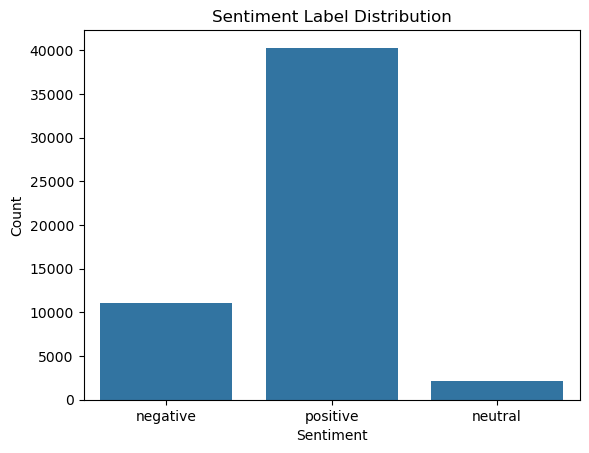

In [10]:
# Plot class distribution

sns.countplot(x=y)

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [11]:
y.unique()

<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str

### Observation

The dataset shows class imbalance, with positive sentiments having the highest number of reviews compared to negative and average sentiments. This imbalance should be considered during model evaluation.

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])

[0 0 0 0 0 0 0 0 2 0]


## Train-Test Split

In [13]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Check shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (42804,)
X_test: (10702,)
y_train: (42804,)
y_test: (10702,)


In [14]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 42804
Testing samples: 10702


## Model Evaluation Function

A reusable model evaluation function was created to train and assess machine learning models using multiple performance metrics. The function calculates the weighted F1 score, precision, recall, classification report, confusion matrix, and cross-validation score to measure model performance and reliability.



In [15]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name ='Model'):

    

    model.fit(X_train, y_train)#training the model

    
    y_pred = model.predict(X_test)#model predictions
    

    # Weighted F1 Score
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Precision & Recall
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    # Classification Report
    report = classification_report(y_test, y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Cross-validation (F1)
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted'
    )
    cv_mean = cv_scores.mean()

    
    # Print Results


    print(" Weighted F1 Score:", round(f1, 4))
    print(" Precision:", round(precision, 4))
    print(" Recall:", round(recall, 4))
    print(" Cross-validation F1 (mean):", round(cv_mean, 4))

    print("\n Classification Report:\n")
    print(report)

    
    # Plot Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    
    # Compare with target F1 = 0.75

    if f1 >= 0.75:
        print(" Model meets target F1 ≥ 0.75")
    else:
        print(" Model does NOT meet target F1 = 0.75")

    return {
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "cv_f1": cv_mean}

#### Modelling Techniques
1. Baseline Model

- TF-IDF + Logistic Regression

A TF-IDF Vectorizer combined with Logistic Regression was used as the baseline NLP model. TF-IDF converted review text into numerical features, while Logistic Regression classified customer sentiment efficiently and provided an interpretable benchmark for evaluating more advanced models

In [16]:
# Baseline Model: TF-IDF + Logistic Regression
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("logreg", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

intermediate_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("xgb", XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
])

 Weighted F1 Score: 0.8269
 Precision: 0.8536
 Recall: 0.8045
 Cross-validation F1 (mean): 0.8254

 Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.71      0.72      2208
           1       0.09      0.23      0.13       434
           2       0.93      0.86      0.89      8060

    accuracy                           0.80     10702
   macro avg       0.58      0.60      0.58     10702
weighted avg       0.85      0.80      0.83     10702



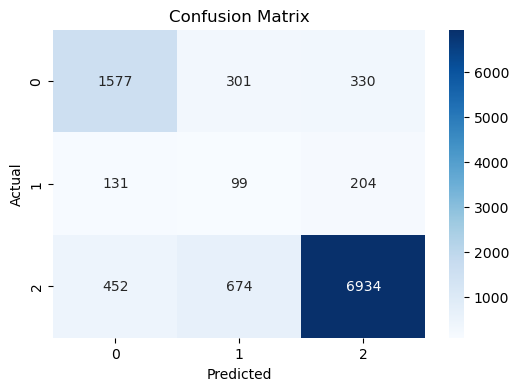

 Model meets target F1 ≥ 0.75


In [17]:
# 4. Evaluate Baseline
baseline_results = evaluate_model(baseline_pipeline, X_train, X_test, y_train, y_test, "Baseline Model")

 Weighted F1 Score: 0.8161
 Precision: 0.8083
 Recall: 0.8453
 Cross-validation F1 (mean): 0.8152

 Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.51      0.63      2208
           1       0.00      0.00      0.00       434
           2       0.85      0.98      0.91      8060

    accuracy                           0.85     10702
   macro avg       0.56      0.50      0.51     10702
weighted avg       0.81      0.85      0.82     10702



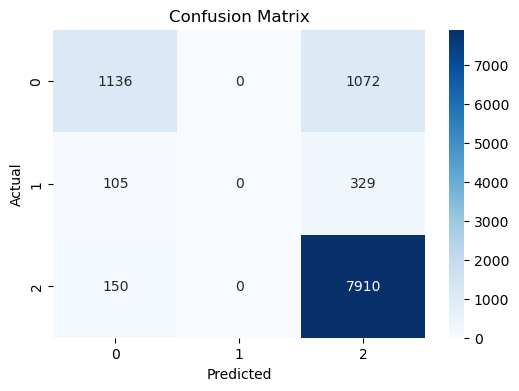

 Model meets target F1 ≥ 0.75


In [18]:
# 5. Evaluate Intermediate
intermediate_results = evaluate_model(intermediate_pipeline, X_train, X_test, y_train, y_test, "Intermediate Model")